# PART 2: CODING PROBLEMS

## Problem 5: Propensity Score Model (Coding)

**Context (tech company):** A SaaS company rolled out an AI assistant feature in a phased rollout. Power users and higher-tier customers were more likely to get early access. You want to estimate the causal effect of the feature on **weekly active minutes**.

**Variables:**
- **D** = 1 if user had access to AI assistant, 0 otherwise
- **Y** = weekly_active_minutes (outcome)
- **plan_tier**: 0=free, 1=pro, 2=enterprise
- **tenure_days**: days since signup (0–365)
- **prior_sessions**: sessions in past 30 days before launch
- **platform**: 0=web, 1=mobile
- **signup_cohort**: 0=Q1, 1=Q2, 2=Q3 (quarter of signup)

**True causal effect:** +15 minutes per week. Treatment is *not* random—selection on observables.

**Your tasks:**

1. **Use the simulated data** below (or generate your own with the same DGP).

2. **Estimate the propensity score** e(X) = Pr(D=1|X) using logistic regression of D on all covariates. Print the model summary. Which covariates most increase the probability of treatment?

3. **Add fitted propensity scores** to the dataset.

4. **Check overlap:** Plot propensity score distributions for treated vs control (KDE or histogram). Is overlap sufficient?

5. **Compute ATE via IPW.** Compare naive ATE, IPW ATE, and true effect (15). Briefly interpret.

In [4]:
pip install scikit-learn


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 32.5 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

np.random.seed(123)

# Simulated data: AI assistant feature rollout (phased, not random)
n = 600
plan_tier = np.random.choice([0, 1, 2], n, p=[0.5, 0.35, 0.15])
tenure_days = np.random.randint(0, 366, n)
prior_sessions = np.random.poisson(12, n) + np.random.randint(0, 20, n)
platform = np.random.choice([0, 1], n, p=[0.6, 0.4])
signup_cohort = np.random.choice([0, 1, 2], n, p=[0.4, 0.35, 0.25])

# Treatment: higher tier, tenure, prior sessions, mobile → more likely to get feature
logit_p = -2.0 + 0.5*plan_tier + 0.003*tenure_days + 0.02*prior_sessions + 0.4*platform + 0.2*signup_cohort
ps_true = 1 / (1 + np.exp(-np.clip(logit_p, -10, 10)))
D = (np.random.uniform(0, 1, n) < ps_true).astype(int)

# Outcome: weekly_active_minutes. True effect of feature = +15 min
Y = 80 + 15*D + 8*plan_tier + 0.05*tenure_days + 0.8*prior_sessions + 5*platform + 3*signup_cohort + np.random.normal(0, 12, n)
Y = np.maximum(Y, 0)

df = pd.DataFrame({
    'plan_tier': plan_tier, 'tenure_days': tenure_days, 'prior_sessions': prior_sessions,
    'platform': platform, 'signup_cohort': signup_cohort, 'D': D, 'weekly_active_minutes': Y
})

print("Dataset: AI assistant feature rollout")
print(f"  n = {len(df)}, Treated: {D.sum()}, Control: {n - D.sum()}")
print(f"  True causal effect: +15 min/week")
print(df.head(10))

Dataset: AI assistant feature rollout
  n = 600, Treated: 254, Control: 346
  True causal effect: +15 min/week
   plan_tier  tenure_days  prior_sessions  platform  signup_cohort  D  \
0          1          231              16         1              2  0   
1          0          276              28         0              2  0   
2          0          345              21         0              1  1   
3          1          353              23         0              1  1   
4          1           39              15         0              0  0   
5          0          205              28         0              0  0   
6          2          298              17         0              0  0   
7          1           58              31         0              0  1   
8          0           48              14         1              2  0   
9          0          174               9         0              2  0   

   weekly_active_minutes  
0             132.725826  
1             114.294894  
2   


Logistic Regression Coefficients:
  plan_tier           : 0.5216
  tenure_days         : 0.0022
  prior_sessions      : -0.0049
  platform            : 0.4223
  signup_cohort       : 0.2009

  Most important: plan_tier

Propensity score summary:
count    600.000
mean       0.423
std        0.118
min        0.197
25%        0.332
50%        0.412
75%        0.499
max        0.783
Name: ps, dtype: float64

── Final Results ─────────────────────────
  Naive ATE (simple difference): 18.80
  IPW ATE   (after weighting):   15.39
  True ATE  (ground truth):      15.00

  Naive bias: 3.80
  IPW bias:   0.39
nterpretation:
  Naive ATE is upward biased because treated users are power users
  who would have higher active minutes regardless of the feature.
  IPW corrects for this by reweighting , which gives more weight to
  control units that 'look like' treated users, and vice versa.
  IPW ATE should be much closer to the true effect of +15 min.


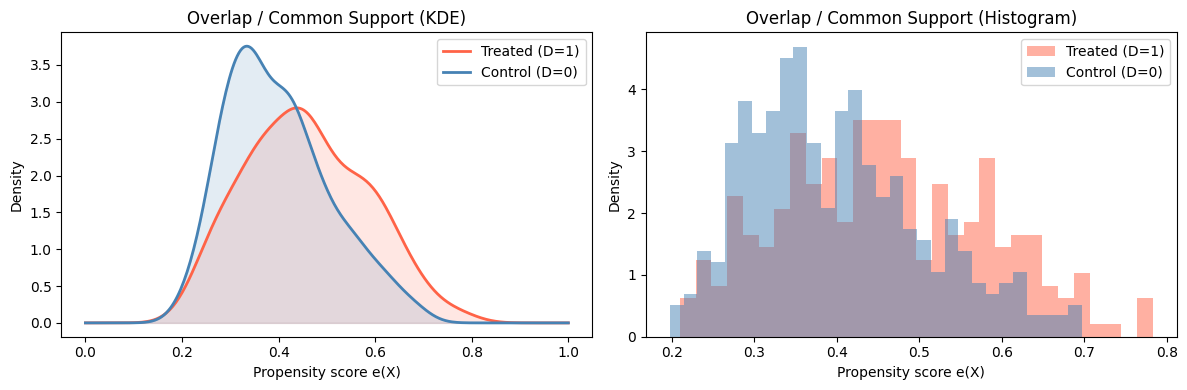

In [10]:
from scipy.stats import gaussian_kde
# YOUR CODE for Problem 5
# Covariates: plan_tier, tenure_days, prior_sessions, platform, signup_cohort
# Outcome: weekly_active_minutes. True effect = 15
# 1. Fit logistic regression: D ~ covariates
covariates = ['plan_tier', 'tenure_days', 'prior_sessions', 'platform', 'signup_cohort']
X = df[covariates].values

lr = LogisticRegression(max_iter=1000)
lr.fit(X, df['D'])

print("\nLogistic Regression Coefficients:")
for name, coef in zip(covariates, lr.coef_[0]):
    print(f"  {name:20s}: {coef:.4f}")
print(f"\n  Most important: {covariates[np.argmax(np.abs(lr.coef_[0]))]}")

# 2. Add df['ps'] = fitted propensity scores
df['ps'] = lr.predict_proba(X)[:, 1]
print(f"\nPropensity score summary:")
print(df['ps'].describe().round(3))

# 3. Plot overlap (KDE or histogram)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, kind in zip(axes, ['kde', 'hist']):
    for grp, lbl, col in [(1,'Treated (D=1)','tomato'), (0,'Control (D=0)','steelblue')]:
        vals = df[df.D==grp]['ps']
        if kind == 'kde':
            kde = gaussian_kde(vals)
            xs  = np.linspace(0, 1, 300)
            ax.plot(xs, kde(xs), label=lbl, color=col, lw=2)
            ax.fill_between(xs, kde(xs), alpha=0.15, color=col)
        else:
            ax.hist(vals, bins=30, alpha=0.5, color=col, label=lbl, density=True)
    ax.set_xlabel('Propensity score e(X)')
    ax.set_ylabel('Density')
    ax.set_title('Overlap / Common Support ' + ('(KDE)' if kind=='kde' else '(Histogram)'))
    ax.legend()

plt.tight_layout()
plt.savefig('overlap.png', dpi=150)

# 4. Compute ATE via IPW (clip ps to avoid extreme weights)

df['ps_clip'] = df['ps'].clip(0.05, 0.95)

e  = df['ps_clip']
D_ = df['D']
Y_ = df['weekly_active_minutes']

# ATE weights
w_treated = D_ / e
w_control = (1 - D_) / (1 - e)

ipw_ate = (w_treated * Y_).sum() / w_treated.sum() - (w_control * Y_).sum() / w_control.sum()

# 5. Compare naive ATE, IPW ATE, true effect (15)
naive_ate = df[df.D==1]['weekly_active_minutes'].mean() - df[df.D==0]['weekly_active_minutes'].mean()

print("\n── Final Results ─────────────────────────")
print(f"  Naive ATE (simple difference): {naive_ate:.2f}")
print(f"  IPW ATE   (after weighting):   {ipw_ate:.2f}")
print(f"  True ATE  (ground truth):      15.00")
print(f"\n  Naive bias: {naive_ate - 15:.2f}")
print(f"  IPW bias:   {ipw_ate   - 15:.2f}")
print("""nterpretation:
  Naive ATE is upward biased because treated users are power users
  who would have higher active minutes regardless of the feature.
  IPW corrects for this by reweighting , which gives more weight to
  control units that 'look like' treated users, and vice versa.
  IPW ATE should be much closer to the true effect of +15 min.""")
